<a href="https://colab.research.google.com/github/raphasandes/Auditoria-Vendas-e-Lucratividade/blob/main/Regress%C3%A3o_Aplicada_%C3%A0_Engenharia_de_Materiais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1) Importando bibliotecas**

In [1]:
#Manipulação de dados
import pandas as pd
import numpy as np

In [2]:
#Visualização
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Modelagem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [4]:
#Métricas
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# **2) Carregando o arquivo**

In [5]:
#Carregando dataset do projeto
df = pd.read_csv("dados_concreto_-_Sheet1.csv")

In [6]:
#Visualizando as 10 primeiras linhas
df.head(10)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength,Strength Category
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99,Alto
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89,Alto
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,40.27,Baixa
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,41.05,Baixa
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,44.30,Baixa
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90.0,47.03,Baixa
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365.0,43.70,Baixa
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28.0,36.45,Baixa
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28.0,45.85,Baixa
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28.0,39.29,Baixa


# **3) Análise Exploratória (EDA)**

In [7]:
#Verificando os dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         2029 non-null   float64
 1   Blast Furnace Slag             2029 non-null   float64
 2   Fly Ash                        2029 non-null   float64
 3   Water                          2029 non-null   float64
 4   Superplasticizer               2029 non-null   float64
 5   Coarse Aggregate               2029 non-null   float64
 6   Fine Aggregate                 2029 non-null   float64
 7   Age                            2029 non-null   float64
 8   Concrete compressive strength  2020 non-null   float64
 9   Strength Category              2029 non-null   object 
dtypes: float64(9), object(1)
memory usage: 158.6+ KB


In [8]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2020.000000
mean,415.147610,107.776688,78.604091,264.240315,9.045293,1444.538492,1139.313258,67.255643,35.886683
std,237.133806,145.230234,106.149019,111.056771,10.239884,604.194394,481.913282,103.260526,16.860121
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.100000
25%,250.000000,0.000000,0.000000,182.000000,0.000000,967.100000,776.400000,14.000000,23.500000
50%,350.400000,26.000000,0.000000,206.000000,7.800000,1104.000000,889.000000,28.000000,34.675000
75%,512.400000,187.000000,136.200000,345.800000,13.600000,1911.800000,1502.800000,75.600000,46.230000
max,1487.600000,923.700000,500.900000,639.900000,83.700000,3150.000000,2779.300000,1022.000000,87.200000


In [10]:
#Verificando existência de dados nulos
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Concrete compressive strength,9
Strength Category,0


In [11]:
#Eliminando linhas que estão incompletas (Concrete compressive strength) - representam apenas 0,5% do total.
df = df.dropna()

In [12]:
#Testando se ainda há valores nulos
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Concrete compressive strength,0
Strength Category,0


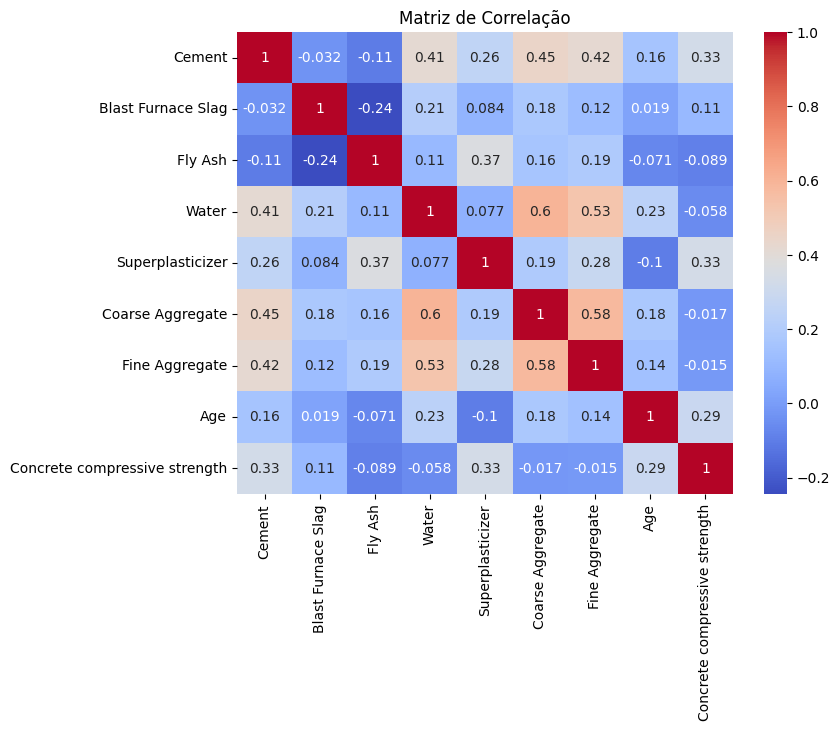

In [15]:
#Criação de matriz de correlação, para verificar quais variáveis têm mais correção com "Concrete compressive strength"
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

Análise: A matriz indica que as variáveis mais associadas à resistência do concreto são Cement (0.33), Superplasticizer (0.33) e Age (0.29), apresentando correlação positiva moderada. Demais variáveis apresentam correlação fraca ou negativa. Como nenhuma variável apresenta correlação forte, a relação entre os componentes e a resistência do concreto pode não ser puramente linear, justificando o uso de Random Forest.

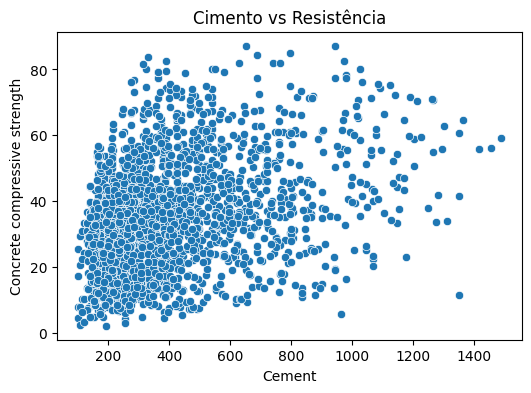

In [28]:
#Cimento versus Resistência
plt.figure(figsize=(6,4))
sns.scatterplot(x='Cement', y='Concrete compressive strength', data=df)
plt.title("Cimento vs Resistência")
plt.xlabel("Cement")
plt.ylabel("Concrete compressive strength")
plt.show()

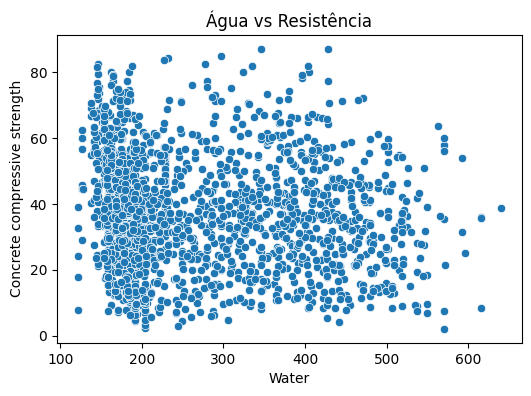

In [29]:
#Água versus Resistência
plt.figure(figsize=(6,4))
sns.scatterplot(x='Water', y='Concrete compressive strength', data=df)
plt.title("Água vs Resistência")
plt.xlabel("Water")
plt.ylabel("Concrete compressive strength")
plt.show()

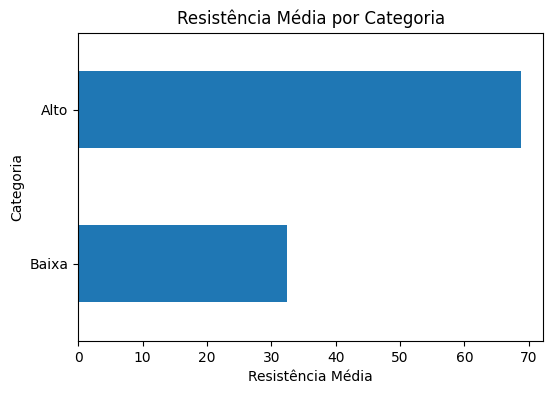

,Concrete compressive strength
Strength Category,
Baixa,32.488236
Alto,68.810265


In [30]:
#Resistência por Categoria
media_categoria = df.groupby("Strength Category")["Concrete compressive strength"].mean().sort_values()

plt.figure(figsize=(6,4))
media_categoria.plot(kind="barh")
plt.title("Resistência Média por Categoria")
plt.xlabel("Resistência Média")
plt.ylabel("Categoria")
plt.show()

media_categoria

# **4) Tratamento de Dados**

In [25]:
#One-Hot Encoding
df_model = pd.get_dummies(df, columns=["Strength Category"], drop_first=True)

In [26]:
#Separando variáveis
X = df_model.drop("Concrete compressive strength", axis=1)
y = df_model["Concrete compressive strength"]

In [27]:
#Divisão entre Grupo Teste e Grupo Treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **5) Treinamento de modelo - Random Forest**

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest")
print("R²:", r2_rf)
print("MAE:", mae_rf)

Random Forest
R²: 0.8176825520328866
MAE: 5.008484678217823


Random Forest

R²: 0.8176825520328866

MAE: 5.008484678217823

# **6) Modelo 6 - Regressão Linear**

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Regressão Linear")
print("R²:", r2_lr)
print("MAE:", mae_lr)

Regressão Linear
R²: 0.5193022302862832
MAE: 9.344575101697886


Regressão Linear

R²: 0.5193022302862832

MAE: 9.344575101697886

# **7) Comparação de modelos**

In [33]:
comparacao = pd.DataFrame({
    "Modelo": ["Random Forest", "Regressão Linear"],
    "R²": [r2_rf, r2_lr],
    "MAE": [mae_rf, mae_lr]
})

comparacao

,Modelo,R²,MAE
0,Random Forest,0.817683,5.008485
1,Regressão Linear,0.519302,9.344575


# **8) Importância das Variáveis (Random Forest)**

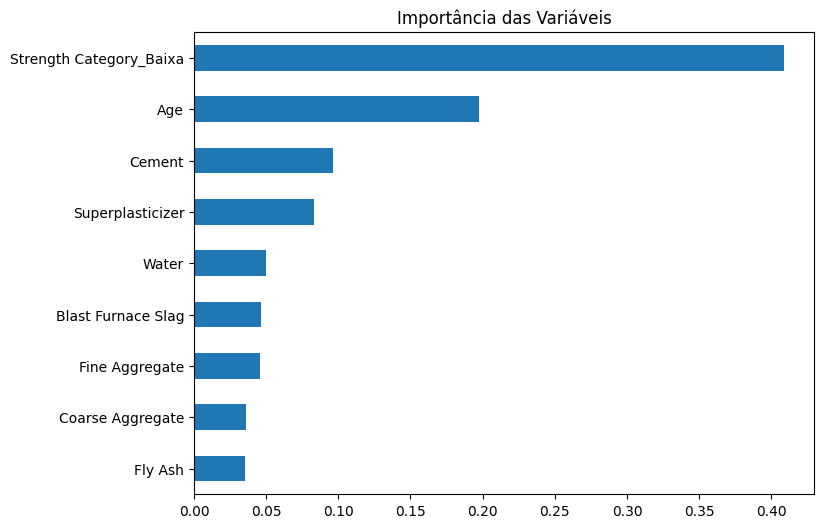

In [34]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Importância das Variáveis")
plt.show()

# **10) RMSE**

In [38]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Random Forest RMSE:", rmse_rf)
print("Linear Regression RMSE:", rmse_lr)

Random Forest RMSE: 7.057494508505631
Linear Regression RMSE: 11.459679877598242


# **11) Gráfico Real versus Previsto**

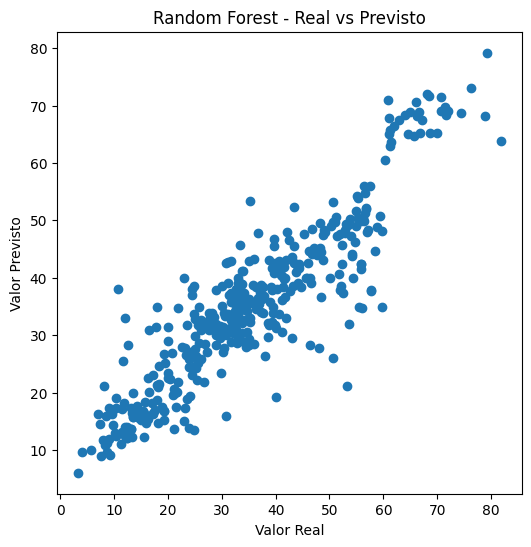

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Random Forest - Real vs Previsto")
plt.show()

# **12) Analisando resíduos**

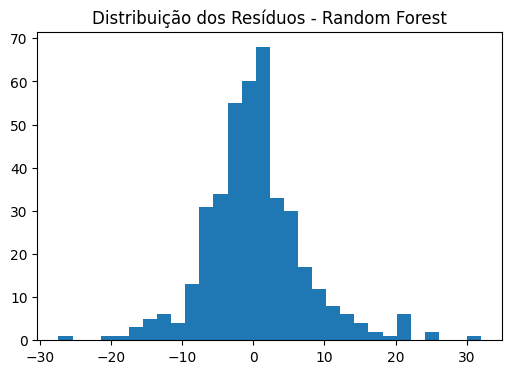

In [40]:
residuos = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.hist(residuos, bins=30)
plt.title("Distribuição dos Resíduos - Random Forest")
plt.show()

# **Predição de um Novo Cenário (Simulação)**

In [42]:
novo_concreto = pd.DataFrame({
    'Cement': [550],
    'Blast Furnace Slag': [150],
    'Fly Ash': [0],
    'Water': [180],
    'Superplasticizer': [2.5],
    'Coarse Aggregate': [1000],
    'Fine Aggregate': [700],
    'Age': [25],
    'Strength Category_Baixa': [0]  # Alterado de 'Strength Category_Alta' para 'Strength Category_Baixa'
})

previsao = rf.predict(novo_concreto)

print("Resistência prevista:", previsao[0])

Resistência prevista: 72.11609999999997


# **Conclusão**

A análise exploratória indicou que as variáveis Cement, Superplasticizer e Age apresentaram as maiores correlações positivas com a resistência do concreto, sugerindo que tanto a composição química quanto o tempo de cura influenciam o desempenho mecânico do material.

Foram comparados os modelos de Random Forest Regressor e Regressão Linear. O modelo Random Forest apresentou melhor desempenho, com R² de 0.8177, indicando que 81,8% da variabilidade da resistência do concreto é explicada pelas variáveis utilizadas. Além disso, o erro absoluto médio (MAE) foi de 5,01 MPa, demonstrando boa precisão preditiva.

Esse resultado sugere que as relações entre os componentes do concreto e sua resistência não são puramente lineares, sendo melhor capturadas por modelos baseados em árvores de decisão, como o Random Forest.

A simulação realizada para um novo cenário de mistura reforça a aplicabilidade prática do modelo, que pode ser utilizado como ferramenta de apoio à tomada de decisão na produção de concreto, contribuindo para otimização de custos, planejamento produtivo e melhoria da eficiência técnica na construção civil.

Conclui-se que a aplicação de técnicas de machine learning na engenharia de materiais é uma abordagem eficaz para previsão de propriedades mecânicas, oferecendo suporte estratégico para processos industriais.